In [23]:
from typing import Annotated

from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage, AIMessage, BaseMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated

In [24]:
load_dotenv()

True

In [25]:
llm = ChatGroq(model='openai/gpt-oss-120b')

In [26]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [27]:
def chat_node(state: ChatState):
    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a question",
        "question": state['messages'][-1].content,
        "instruction": "Approve this question? Yes/No"
    })

    if decision['approved'] == "no":
        return {"messages": [AIMessage(content="Not Approveed")]}
    
    result = llm.invoke(state['messages'])
    return {'messages': [result]}


In [28]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = InMemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

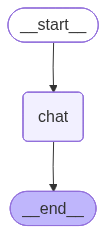

In [29]:
app

In [30]:
config = {'configurable': {'thread_id': 123}}

initial_input = {'messages': [HumanMessage(content="Explain Gradient descent in simple terms")]}
result = app.invoke(initial_input, config=config)

In [31]:
result

{'messages': [HumanMessage(content='Explain Gradient descent in simple terms', additional_kwargs={}, response_metadata={}, id='e421eb1f-dd55-4c6e-85c5-a6e009eef89e')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a question', 'question': 'Explain Gradient descent in simple terms', 'instruction': 'Approve this question? Yes/No'}, id='89a42c56971657a2d76ad2d119afc727')]}

In [32]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a question',
 'question': 'Explain Gradient descent in simple terms',
 'instruction': 'Approve this question? Yes/No'}

In [33]:
user_input = input(f"Backend message - {message}, approve this yes or no")

In [34]:
final_result = app.invoke(Command(resume={'approved': user_input}), config=config)

In [35]:
final_result

{'messages': [HumanMessage(content='Explain Gradient descent in simple terms', additional_kwargs={}, response_metadata={}, id='e421eb1f-dd55-4c6e-85c5-a6e009eef89e'),
  AIMessage(content='**What is gradient descent?**  \nIt’s a simple, step‑by‑step recipe that helps a computer “learn” the best answer to a problem by slowly improving its guess, one little move at a time.\n\n---\n\n## 1. The basic idea (with a picture)\n\nImagine you’re standing on a hilly landscape at night, and you want to find the lowest point (the bottom of a valley). You can’t see the whole map, but you can feel the slope of the ground right where you’re standing.\n\n- **If the ground slopes downward to the north, you take a small step north.**  \n- **If it slopes downward to the east, you step east.**  \n- **If the slope is flat, you’re already at a low spot and you stop.**\n\nBy repeatedly feeling the slope and taking tiny steps downhill, you’ll eventually end up at (or very near) the lowest point.\n\nThat’s exact